# Cutana to colour cutouts

Given a small list of real Euclid sources, this notebook fetches their
pixel data straight from the Euclid MER tile mosaics using
[Cutana](https://github.com/esa/Cutana) (ESA), then renders colour RGB
images from those pixels using four independent colour rendering tools.
It needs one companion file from its parent repo, `render.py` (the module
providing `render_cutout` below): copy it into the same directory as this
notebook, or point `RENDER_MODULE_DIR` at wherever you put it. Everything
else needed to run it is a `pip install` away.

Two stages:

1. **Fetch**: raw multi-band pixel data straight from Euclid MER tile
   mosaics via Cutana's Python API, `cutana.create_cutouts_direct()`, no
   intermediate per-object FITS cache, no UI. Cutouts are **101x101
   pixels** (native VIS pixel scale, 0.1 arcsec/px).
2. **Render**: those bands to colour RGB with azulero, STCI and
   bulk_euclid, plus a separate eummy example (eummy needs the whole tile
   mosaic rather than a cutout array, see the last section).

## The tools

- **[Cutana](https://github.com/esa/Cutana)**
  ([arXiv:2511.04429](https://arxiv.org/abs/2511.04429)), ESA: a
  high-performance Python pipeline for creating astronomical image
  cutouts from large FITS datasets.
- **[azulero](https://kabasset.github.io/azulero/v2.0.0/index.html)**
  (Basset et al., CNES; [PyPI](https://pypi.org/project/azulero/)): LRGB
  composite from all 4 bands, asinh stretch, per-band sharpening,
  dead-pixel inpainting, hue/saturation mapping. Requires **v2.0+** (a
  near-total rewrite from 1.x, the API used here won't work on older
  versions).
- **STCI** (SpaceTelescopeColorImage, courtesy Tian Li;
  [PyPI](https://pypi.org/project/STCI/)): a PixInsight-like pipeline,
  background neutralisation, colour calibration, linked STF/histogram
  transform, luminosity replacement, SCNR, saturation.
- **[bulk-euclid-cutouts](https://github.com/mwalmsley/bulk-euclid-cutouts)**
  (Walmsley, M.): arcsinh and MTF (midtone-transfer-function) colour
  stretches, several VIS/Y/J band-combination variants. Not on PyPI,
  cloned locally (see Install below).
- **[eummy](https://github.com/schirmermischa/eummy)** (Schirmer, M.):
  contrast-based rendering with configurable black/white thresholds.
  Works differently from the other three: it's a CLI tool that processes
  a whole tile FITS mosaic at once (it does its own cutout extraction
  internally), not a per-object cutout array. See the last section.

## Install

```bash
pip install cutana eummy azulero STCI

# bulk_euclid isn't on PyPI, clone and point BULK_ROOT at it below
git clone https://github.com/mwalmsley/bulk-euclid-cutouts
pip install -e ./bulk-euclid-cutouts
```

## Assumptions

- Runs on a machine with the Euclid MER tile mosaics mounted locally (e.g.
  an ESA Datalabs workspace). Cutana and eummy both read directly from
  those FITS files; nothing is downloaded over the network.
- `bulk_euclid` is a local clone (see `BULK_ROOT` below), not a PyPI
  package.
- The 3 example sources below already have their tile and release
  directory resolved (see Step 1). If you bring your own sources and only
  know their RA/Dec, you'll need to resolve which tile each one falls in
  first; the parent repo's `scripts/build_tile_centres.py` plus a
  nearest-tile-centre lookup does this for an arbitrary list, but that's
  left out of this notebook.
- **`config.apply_flux_conversion = False` is required** when fetching via
  Cutana. Cutana's default config converts pixel values from ADU/s to
  Jansky using the tile's `MAGZERO` header keyword, but azulero, STCI and
  bulk_euclid all do their own zeropoint math on raw ADU/s internally
  (azulero's `AZUL_ZERO` below is literally the MER `MAGZERO` values).
  Leaving Cutana's conversion on double-converts the pixels down to a
  scale of about 1e-8, far below any renderer's expected input range, so
  azulero in particular renders essentially all black.
- eummy needs an absolute path for `--path`; a relative one makes it
  double the path internally and fail.


In [1]:
import glob
import os
import re
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from PIL import Image

from cutana import create_cutouts_direct, get_default_config

# render.py is the one companion file this notebook needs from its parent
# repo (margres/euclid_cutouts) -- copy it next to this notebook, or point
# RENDER_MODULE_DIR at wherever you put it.
sys.path.insert(0, os.environ.get("RENDER_MODULE_DIR", "/media/user/euclid_cutouts/euclid_cutouts"))
from render import render_cutout

BULK_ROOT = os.environ.get("BULK_EUCLID_ROOT", "/media/user/bulk-euclid-cutouts")
CUTOUT_PIXELS = 101       # native VIS pixel scale, 0.1 arcsec/px
VIS_ARCSEC_PER_PX = 0.1


## Step 1: three real grade-A lenses

Picked (`random_state=42`) from
`Catalogs/all_cand_in_q1_randomtag_Mikerecentered_grade_A.csv`, a
catalogue of 335 grade-A strong-lens candidates used across this
workspace, filtered to `Grade == "A"` and to sources whose tile is present
on this machine. All three are credited to Walmsley+25 in that
catalogue's `Reference` column. `tile_index` and `release_dir` are already
resolved below (see Assumptions above for arbitrary sources).

Swap in your own sources here: you need an ID, RA, Dec, tile index and
release directory per source.


In [2]:
sources = pd.DataFrame([
    {"SourceID": "102019592_NEG606434619500983922", "RA": 60.643416, "Dec": -50.098453,
     "tile_index": 102019592, "release_dir": "/media/home/data/euclid_idr1/DR1/R2"},
    {"SourceID": "102021492_NEG580553783482399812", "RA": 58.055346, "Dec": -48.239974,
     "tile_index": 102021492, "release_dir": "/media/home/data/euclid_idr1/DR1/R2"},
    {"SourceID": "102022972_NEG597052478465695317", "RA": 59.705233, "Dec": -46.569559,
     "tile_index": 102022972, "release_dir": "/media/home/data/euclid_idr1/DR1/R2"},
])
sources


,SourceID,RA,Dec,tile_index,release_dir
0,102019592_NEG606434619500983922,60.643416,-50.098453,102019592,/media/home/data/euclid_idr1/DR1/R2
1,102021492_NEG580553783482399812,58.055346,-48.239974,102021492,/media/home/data/euclid_idr1/DR1/R2
2,102022972_NEG597052478465695317,59.705233,-46.569559,102022972,/media/home/data/euclid_idr1/DR1/R2


## Resolving FITS paths

Each tile's per-band mosaic FITS files follow a fixed naming convention,
`EUC_MER_BGSUB-MOSAIC-{BAND}_TILE{tile}-{HASH}_{timestamp}Z_....fits`, but
a tile can have more than one reprocessing run for the same band. When
that happens we open each candidate and check whether it actually has
non-zero data at the source's RA/Dec, preferring the one that does (and
the chronologically newest among ties).


In [3]:
def pick_best_coverage(matches: list[str], ra: float, dec: float) -> str:
    if len(matches) == 1:
        return matches[0]
    by_time = sorted(matches, key=lambda f: re.search(r"_(\d{8}T\d{6})", f).group(1))
    has_data = []
    for path in by_time:
        try:
            with fits.open(path, memmap=True) as hdul:
                data = hdul[0].data
                wcs = WCS(hdul[0].header)
                x, y = wcs.world_to_pixel_values(ra, dec)
                x, y = int(round(float(x))), int(round(float(y)))
                has_data.append(data[y, x] != 0)
        except Exception:
            has_data.append(False)
    for path, ok in zip(reversed(by_time), reversed(has_data)):
        if ok:
            return path
    return by_time[-1]


def find_fits_paths(tile_index: int, bands: list[str], release_dir: str,
                    band_to_instrument: dict[str, str],
                    ra: float, dec: float) -> list[str] | None:
    paths = []
    for band in bands:
        instrument = band_to_instrument[band]
        band_hyphen = band.replace("_", "-")
        pattern = (f"{release_dir}/MER/{tile_index}/{instrument}/"
                  f"EUC_MER_BGSUB-MOSAIC-{band_hyphen}_TILE{tile_index}-*.fits")
        matches = glob.glob(pattern)
        if not matches:
            return None
        paths.append(pick_best_coverage(matches, ra, dec))
    return paths


BAND_TO_INST = {"VIS": "VIS", "NIR_Y": "NISP", "NIR_J": "NISP", "NIR_H": "NISP"}


## Step 2: fetch raw bands via Cutana

`cutana.create_cutouts_direct()` reads straight from the tile mosaics and
returns cutout arrays in memory, nothing touches disk. We fetch VIS,
NIR-Y and NIR-J together (Cutana's band-name convention is hyphenated)
using **identity channel weights** (`[1,0,0]`, `[0,1,0]`, `[0,0,1]`) to get
the three bands back *un-mixed*, rather than Cutana's own RGB composite.
We want the raw pixels so we can apply our own colour stretches (azulero,
STCI, bulk_euclid) downstream. NIR-H is fetched separately (Cutana's
output is always 3-channel per call, so a 4th band needs its own call).
Leaving NIR-H all-zero instead of fetching it would make azulero's
dead-pixel inpainting fail (see the "renderers" note below).


In [4]:
CUTANA_BANDS = ["NIR_Y", "NIR_J", "VIS"]  # Cutana's own convention order
sources["diameter_pixel"] = CUTOUT_PIXELS


def fetch_raw(bands, weights):
    """Fetch exactly `bands` (Cutana requires fits_file_paths to match
    selected_extensions/channel_weights 1:1, or it refuses, see
    'Configuration would silently drop tensor extensions', so each band
    set gets its own path-resolution + catalogue, even if it repeats work
    across calls."""
    catalogue = sources.copy()
    catalogue["fits_file_paths"] = [
        str(find_fits_paths(int(row.tile_index), bands, row.release_dir,
                            BAND_TO_INST, ra=row.RA, dec=row.Dec))
        for row in sources.itertuples()
    ]

    config = get_default_config()
    config.target_resolution = CUTOUT_PIXELS
    config.selected_extensions = [{"name": b.replace("_", "-"), "ext": "PrimaryHDU"} for b in bands]
    config.channel_weights = weights
    config.normalisation_method = "none"    # raw pixels, we stretch ourselves downstream
    config.apply_flux_conversion = False    # keep native ADU/s, see Assumptions above

    out = {}
    cols = ["SourceID", "RA", "Dec", "diameter_pixel", "fits_file_paths"]
    for batch in create_cutouts_direct(catalogue[cols], config):
        for cutout, meta in zip(batch["cutouts"], batch["metadata"]):
            out[meta["source_id"]] = cutout
    return out


# Un-mixed VIS/NIR-Y/NIR-J, one array per source, channel order [NIR-Y, NIR-J, VIS].
vis_y_j = fetch_raw(CUTANA_BANDS, {
    "NIR-Y": [1.0, 0.0, 0.0], "NIR-J": [0.0, 1.0, 0.0], "VIS": [0.0, 0.0, 1.0],
})
# NIR-H on its own (real data in channel 0 of the 3-channel output).
nir_h = fetch_raw(["NIR_H"], {"NIR-H": [1.0, 0.0, 0.0]})

print(f"Fetched {len(vis_y_j)} cutouts, shape={next(iter(vis_y_j.values())).shape}")


/media/user/envs/feat/lib/python3.11/site-packages/cutana/cutout_process_utils.py:470: RuntimeWarning: invalid value encountered in cast
  np.round(diameter_arcsecs / first_pixel_scale).astype(int),


/media/user/envs/feat/lib/python3.11/site-packages/cutana/cutout_process_utils.py:470: RuntimeWarning: invalid value encountered in cast
  np.round(diameter_arcsecs / first_pixel_scale).astype(int),


Fetched 3 cutouts, shape=(101, 101, 3)


## Step 3: assemble IYJH arrays and render colour images

The renderers work on `(4, H, W)` **IYJH** arrays (VIS, NIR-Y, NIR-J,
NIR-H, in that fixed order). Below renders through all 8 available
colour stretches: azulero, STCI, and bulk_euclid's 6 variants (arcsinh
and MTF, VIS-only through VIS+Y+J triple-band).

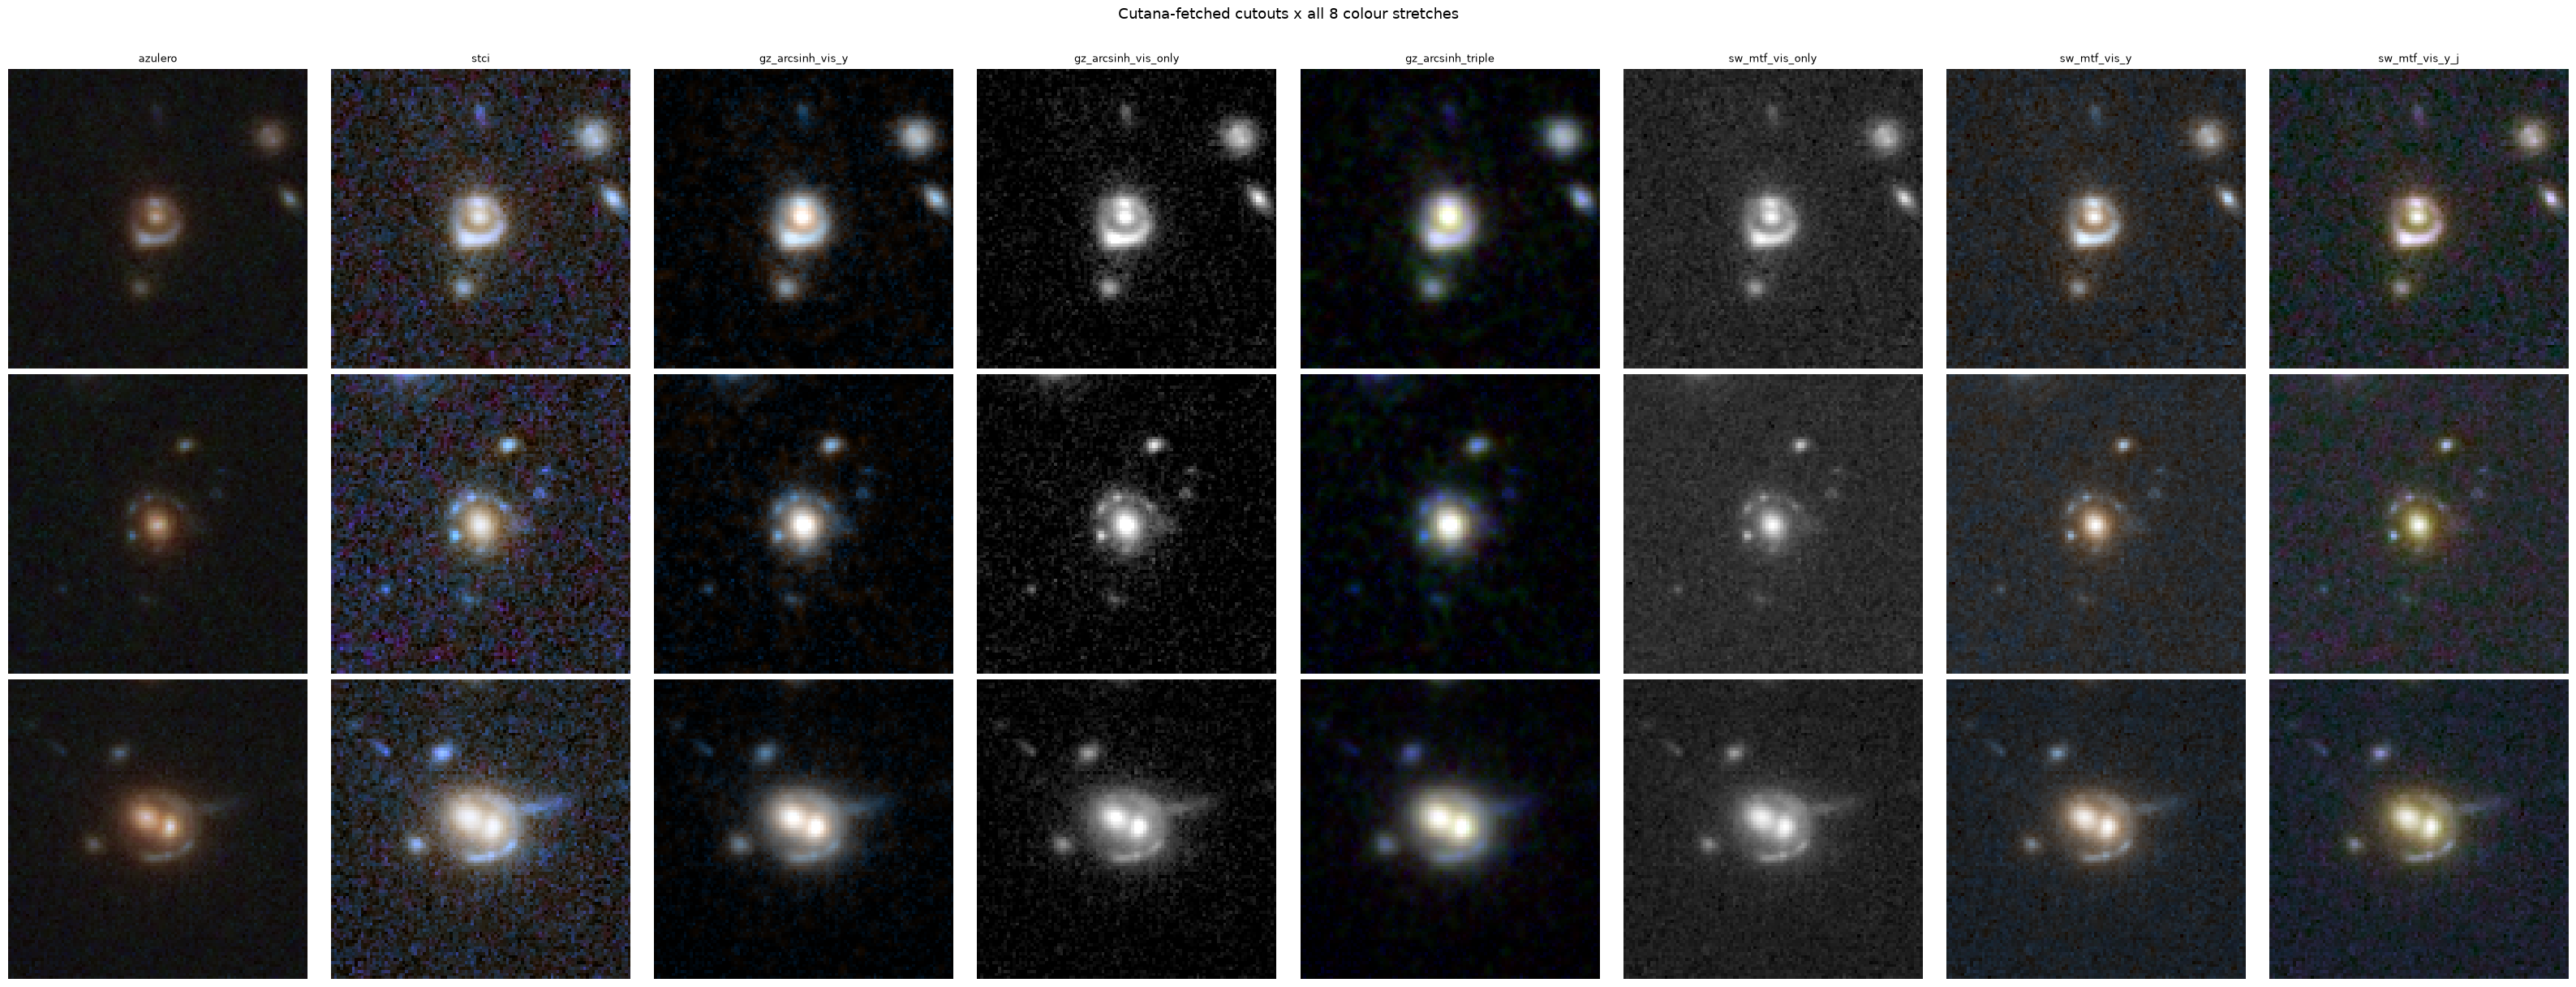

In [5]:
def to_iyjh(source_id: str) -> np.ndarray:
    raw = vis_y_j[source_id]
    iyjh = np.zeros((4,) + raw.shape[:2], dtype=np.float32)
    iyjh[0] = raw[..., 2]                  # VIS
    iyjh[1] = raw[..., 0]                  # NIR_Y
    iyjh[2] = raw[..., 1]                  # NIR_J
    iyjh[3] = nir_h[source_id][..., 0]     # NIR_H
    return iyjh


ALL_BULK_VARIANTS = [
    "gz_arcsinh_vis_y",     # VIS+Y composite (arcsinh)
    "gz_arcsinh_vis_only",  # VIS-only (arcsinh)
    "gz_arcsinh_triple",    # VIS+Y+J three-band (arcsinh)
    "sw_mtf_vis_only",      # VIS-only (midtone transfer)
    "sw_mtf_vis_y",         # VIS+Y (midtone transfer + LAB luminosity)
    "sw_mtf_vis_y_j",       # VIS+Y+J (midtone transfer + LAB luminosity)
]
renderers = ["azulero", "stci"] + ALL_BULK_VARIANTS
stems = list(vis_y_j.keys())

fig, axes = plt.subplots(len(stems), len(renderers),
                         figsize=(4 * len(renderers), 4 * len(stems)))
for row, stem in enumerate(stems):
    iyjh = to_iyjh(stem)
    out = render_cutout(iyjh, renderers=["azulero", "stci", "bulk_euclid"],
                        bulk_variants=ALL_BULK_VARIANTS, bulk_euclid_root=BULK_ROOT)
    for col, name in enumerate(renderers):
        axes[row, col].imshow(out[name])
        if row == 0:
            axes[row, col].set_title(name, fontsize=9)
        if col == 0:
            axes[row, col].set_ylabel(stem, fontsize=9)
        axes[row, col].axis("off")
plt.suptitle("Cutana-fetched cutouts x all 8 colour stretches", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Step 4: saving the rendered images

`render_cutout` only returns arrays; nothing is written to disk until you
save it yourself. `imshow` above is just for inline preview. Each array is
`(H, W, 3)` `uint8`, so any renderer's output can be saved with
`PIL.Image.fromarray(rgb).save(path)`, one JPEG per source per renderer
below.


In [6]:
colour_out_dir = "cutana_colour_output"

for stem in vis_y_j:
    iyjh = to_iyjh(stem)
    out = render_cutout(iyjh, renderers=["azulero", "stci", "bulk_euclid"],
                        bulk_variants=ALL_BULK_VARIANTS, bulk_euclid_root=BULK_ROOT)
    for name, rgb in out.items():
        out_dir = os.path.join(colour_out_dir, name)
        os.makedirs(out_dir, exist_ok=True)
        Image.fromarray(rgb).save(os.path.join(out_dir, f"{stem}.jpg"), quality=95)

for root, dirs, files in os.walk(colour_out_dir):
    level = root.replace(colour_out_dir, "").count(os.sep)
    print("  " * level + os.path.basename(root) + "/")
    for f in sorted(files):
        print("  " * (level + 1) + f)


cutana_colour_output/
  azulero/
    102019592_NEG606434619500983922.jpg
    102021492_NEG580553783482399812.jpg
    102022972_NEG597052478465695317.jpg
  stci/
    102019592_NEG606434619500983922.jpg
    102021492_NEG580553783482399812.jpg
    102022972_NEG597052478465695317.jpg
  gz_arcsinh_vis_y/
    102019592_NEG606434619500983922.jpg
    102021492_NEG580553783482399812.jpg
    102022972_NEG597052478465695317.jpg
  gz_arcsinh_vis_only/
    102019592_NEG606434619500983922.jpg
    102021492_NEG580553783482399812.jpg
    102022972_NEG597052478465695317.jpg
  gz_arcsinh_triple/
    102019592_NEG606434619500983922.jpg
    102021492_NEG580553783482399812.jpg
    102022972_NEG597052478465695317.jpg
  sw_mtf_vis_only/
    102019592_NEG606434619500983922.jpg
    102021492_NEG580553783482399812.jpg
    102022972_NEG597052478465695317.jpg
  sw_mtf_vis_y/
    102019592_NEG606434619500983922.jpg
    102021492_NEG580553783482399812.jpg
    102022972_NEG597052478465695317.jpg
  sw_mtf_vis_y_j/
  

## Step 5: saving the raw FITS (batch variant)

The colour JPEGs above are the end product for most uses, but for a larger
batch you may also want the raw cutouts as FITS files on disk, e.g. to
re-render later with different renderer settings without re-fetching from
Cutana. Each file gets 4 extensions, `CHANNEL_1`..`CHANNEL_4` = VIS,
NIR-Y, NIR-J, NIR-H.


In [7]:
fits_out_dir = "cutana_fetched_fits"
os.makedirs(fits_out_dir, exist_ok=True)

for stem in vis_y_j:
    iyjh = to_iyjh(stem)
    hdus = [fits.PrimaryHDU()] + [fits.ImageHDU(data=iyjh[i], name=f"CHANNEL_{i + 1}")
                                  for i in range(4)]
    fits.HDUList(hdus).writeto(os.path.join(fits_out_dir, f"{stem}.fits"), overwrite=True)

print(f"Wrote {len(vis_y_j)} FITS files to {fits_out_dir}/")


Wrote 3 FITS files to cutana_fetched_fits/


## Step 6: eummy (whole tile, not the Cutana-fetched array)

A natural question: can eummy render the cutouts Cutana just fetched? No,
not directly. eummy is a CLI tool that reads a whole tile FITS mosaic and
does its own cutout extraction from RA/Dec internally; it does not accept
a pre-cut cutout array the way `render_cutout` does for azulero, STCI and
bulk_euclid. So it can't consume `vis_y_j`/`nir_h` from Step 2.

What it can reuse is each source's already-known tile and release
directory from Step 1. Below: set up a small per-tile workspace
(symlink the tile's FITS files in), write a tiny RA/Dec catalog eummy
expects, run the `eummy` CLI, then match its output back to sources by
RA/Dec (eummy names its output `TILE{id}_{ra}{dec}.png`).


102019592_NEG606434619500983922: 1 eummy PNG(s) written


102021492_NEG580553783482399812: 1 eummy PNG(s) written


102022972_NEG597052478465695317: 1 eummy PNG(s) written


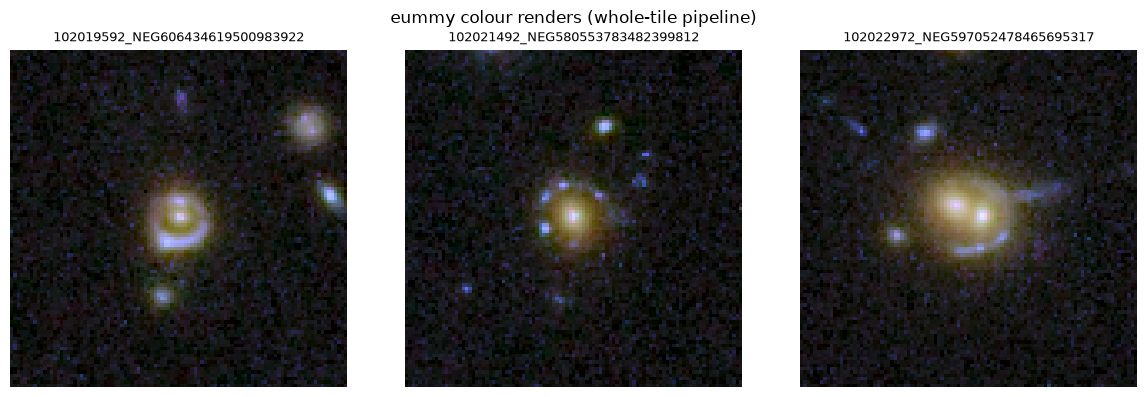

In [8]:
_EUMMY_RE = re.compile(r"^.+_(-?\d+\.\d+)([+-]\d+\.\d+)\.png$")


def find_eummy_exe() -> str:
    exe = shutil.which("eummy")
    if exe:
        return exe
    candidate = os.path.join(os.path.dirname(sys.executable), "eummy")
    if os.path.exists(candidate):
        return candidate
    raise FileNotFoundError("Could not find 'eummy'. Install it with 'pip install eummy'.")


def run_eummy_tile(iyjh_paths, eummy_sources, tile_dir, eummy_out_dir):
    tile_dir = os.path.abspath(tile_dir)
    eummy_out_dir = os.path.abspath(eummy_out_dir)
    os.makedirs(tile_dir, exist_ok=True)
    for path in iyjh_paths:
        link = os.path.join(tile_dir, os.path.basename(path))
        if not os.path.exists(link):
            os.symlink(path, link)

    ra_arr = np.array([s["ra"] for s in eummy_sources], dtype=np.float64)
    dec_arr = np.array([s["dec"] for s in eummy_sources], dtype=np.float64)
    catalog_path = os.path.join(tile_dir, "cutout_catalog.fits")
    fits.BinTableHDU.from_columns([
        fits.Column(name="RA", format="D", array=ra_arr),
        fits.Column(name="DEC", format="D", array=dec_arr),
    ]).writeto(catalog_path, overwrite=True)

    cutout_arcsec = CUTOUT_PIXELS * VIS_ARCSEC_PER_PX
    cmd = [find_eummy_exe(), "--path", tile_dir, "--cutouts", catalog_path,
          f'{cutout_arcsec}"', "--nthreads", "1"]
    subprocess.run(cmd, check=True, capture_output=True)

    os.makedirs(eummy_out_dir, exist_ok=True)
    n_renamed = 0
    for png_path in glob.glob(os.path.join(tile_dir, "TILE*_*.png")):
        match = _EUMMY_RE.match(os.path.basename(png_path))
        if not match:
            continue
        ra, dec = float(match.group(1)), float(match.group(2))
        dra = (ra_arr - ra) * np.cos(np.radians(dec))
        ddec = dec_arr - dec
        i = int(np.argmin(np.hypot(dra, ddec)))
        dest = os.path.join(eummy_out_dir, f"{eummy_sources[i]['id']}.png")
        os.replace(png_path, dest)
        n_renamed += 1
    return n_renamed


EUMMY_BANDS = ["VIS", "NIR_Y", "NIR_J", "NIR_H"]
eummy_out_dir = "cutana_eummy_output"
os.makedirs(eummy_out_dir, exist_ok=True)

for row in sources.itertuples():
    iyjh_paths = find_fits_paths(int(row.tile_index), EUMMY_BANDS, row.release_dir,
                                 BAND_TO_INST, ra=row.RA, dec=row.Dec)
    tile_dir = f"cutana_eummy_output/_tile_{row.tile_index}"
    n = run_eummy_tile(iyjh_paths, [{"id": row.SourceID, "ra": row.RA, "dec": row.Dec}],
                       tile_dir, eummy_out_dir)
    print(f"{row.SourceID}: {n} eummy PNG(s) written")

fig, axes = plt.subplots(1, len(sources), figsize=(4 * len(sources), 4))
for ax, row in zip(axes, sources.itertuples()):
    ax.imshow(Image.open(os.path.join(eummy_out_dir, f"{row.SourceID}.png")))
    ax.set_title(row.SourceID, fontsize=9)
    ax.axis("off")
plt.suptitle("eummy colour renders (whole-tile pipeline)")
plt.tight_layout()
plt.show()


## Cleanup

Everything this notebook wrote to disk lives under three directories:
`cutana_colour_output/` (JPEGs), `cutana_fetched_fits/` (raw FITS) and
`cutana_eummy_output/` (eummy PNGs plus its per-tile scratch workspaces).
Remove them if you don't need to keep the output.


In [9]:
for d in ["cutana_colour_output", "cutana_fetched_fits", "cutana_eummy_output"]:
    shutil.rmtree(d, ignore_errors=True)
print("Cleaned up.")


Cleaned up.
